# Random Imputation

- We randomly fill the missing values with values from the same column (can be used for both numerical and categorical data).
- Preserves the distribution of the data, because we randomly select values from the same column so the probability of selecting a value with high frequency is higher than selecting a value with low frequency.
- Though corr/cov can change as we introduced randomness
- Well suited for linear models
- Can applied using pandas and not sklearn

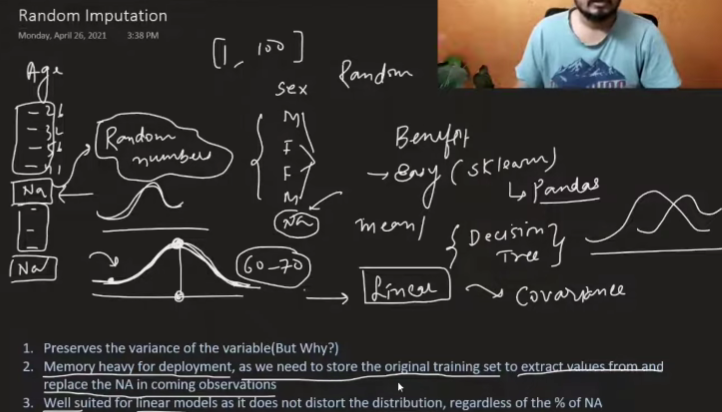

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:
# Randomly impute the missing values in the 'Age_imputed' column using values from the 'Age' column in the training set
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_21664\2860635862.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum())

In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([25.  , 33.  ,  4.  , 33.  , 29.  , 22.  , 14.  , 24.  ,  9.  ,
       19.  , 24.  , 42.  , 33.  , 27.  , 36.  , 20.  , 42.  , 24.  ,
       46.  , 48.  , 36.  , 16.  ,  1.  , 32.  , 60.  , 24.  , 52.  ,
       50.  , 30.  , 22.  , 34.  , 21.  , 57.  , 36.  , 29.  , 24.  ,
       33.  , 14.  , 20.  , 47.  , 26.  , 21.  , 26.  , 25.  ,  0.67,
       20.  , 19.  , 25.  , 47.  , 46.  , 36.  , 34.  , 14.  , 23.  ,
       42.  , 71.  , 28.  , 24.  , 37.  , 34.  , 21.  , 41.  , 24.  ,
        6.  , 39.  , 22.  , 30.  , 56.  ,  3.  , 19.  , 50.  , 34.  ,
       39.  , 30.  ,  9.  , 25.  , 25.  , 23.  , 25.  , 30.  , 49.  ,
       17.  , 42.  , 45.  , 16.  , 45.5 , 17.  , 49.  , 56.  , 19.  ,
       45.  , 45.  ,  2.  , 51.  , 28.  , 52.  ,  0.83, 16.  , 21.  ,
       33.  , 52.  , 71.  , 32.  , 26.  , 20.  , 20.  , 24.  , 40.5 ,
       44.  , 39.  , 62.  , 19.  , 50.  , 50.  , 32.  , 45.5 , 28.  ,
        2.  , 28.5 , 22.  , 18.  , 27.  , 29.  , 20.  , 38.  , 24.  ,
       33.  , 16.  ,

In [13]:
X_train['Age'].isnull().sum()

np.int64(148)

In [14]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,29.0
493,71.0,49.5042,71.0
527,NaN,221.7792,17.0


C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_21664\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_21664\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

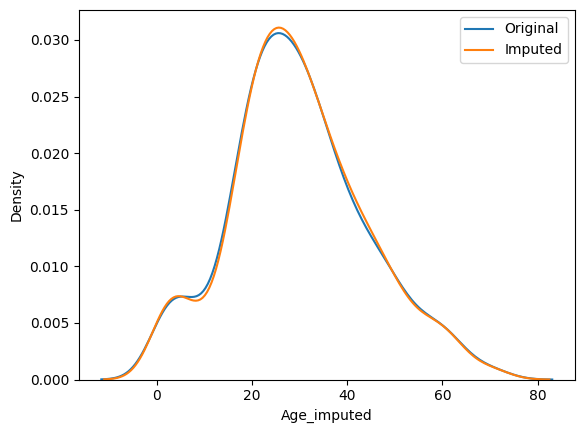

In [15]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

- see no change in the distribution

In [16]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())
# Almost similar variance

Original variable variance:  204.34951339046142
Variance after random imputation:  202.71440943105137


In [17]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()
# but see there is change in covariance

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,55.040752
Age,71.512440,204.349513,204.349513
Age_imputed,55.040752,204.349513,202.714409


<Axes: >

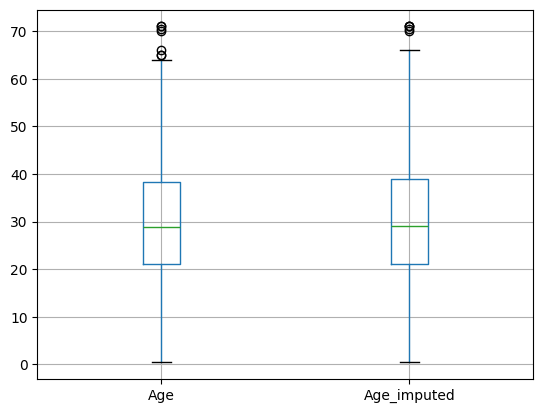

In [18]:
X_train[['Age', 'Age_imputed']].boxplot()
# Similar number of outliers in both the original and imputed variable

- During prod, like for same input we can get different output as we are randomly selecting values from the same column, so we can do something that for the same input we throw the same random value, so we can set a random seed for reproducibility

In [20]:
# Deterministic random imputation using each row's Fare as seed
def impute_age_with_fare_seed(row, source_age):
    if pd.notnull(row['Age']):
        return row['Age']
    return source_age.dropna().sample(
        1, random_state=int(row['Fare'] * 1000)
    ).iloc[0]

X_train['Age_imputed'] = X_train.apply(
    lambda row: impute_age_with_fare_seed(row, X_train['Age']),
    axis=1
)

X_test['Age_imputed'] = X_test.apply(
    lambda row: impute_age_with_fare_seed(row, X_train['Age']),  # use train distribution
    axis=1
)

## For categorical data

In [21]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [22]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [23]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [24]:
X = data # x mei humne pura data daal diya h, kyuki baad me hume jarurat padegi graph plot karne mei
y = data['SalePrice']

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [26]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [27]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
409,Gd,TA,339750,TA,Gd
954,NaN,NaN,127500,NaN,NaN
539,TA,TA,272000,TA,TA
76,NaN,TA,135750,TA,NaN
86,Gd,TA,174000,TA,Gd


In [28]:
# Randomly impute the missing values in the 'GarageQual_imputed' and 'FireplaceQu_imputed' columns using values from the respective columns in the training set

X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_21664\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['G

In [33]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [34]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


- The percentage of categories before and after should be almost similar, as we are randomly selecting values from the same column, so the probability of selecting a value with high frequency is higher than selecting a value with low frequency.
- If its not similar, then its not good as we are not preserving the distribution of the data

In [31]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.648709
TA,0.412439,0.540965
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.032548


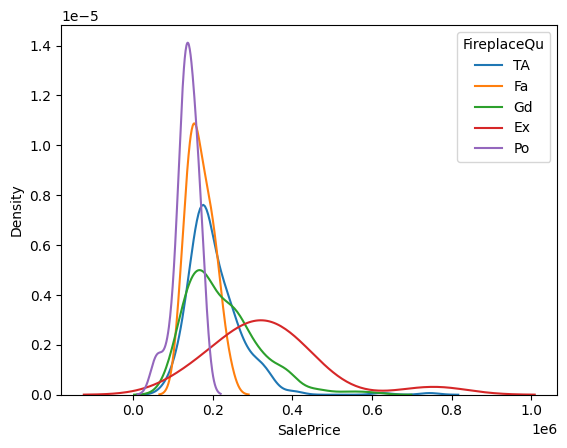

In [36]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category
    )

plt.legend(title='FireplaceQu')
plt.show()

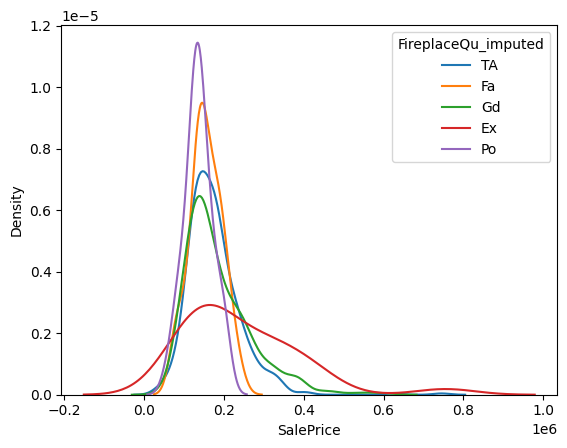

In [37]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu_imputed'] == category],
        x='SalePrice',
        label=category
    )
plt.legend(title='FireplaceQu_imputed')
plt.show()

- See the distribution is changing for some categories, as so much data is missing, so we won't apply randomm imputatuion for FireplaceQu column, but we can apply for GarageQual column as the distribution is not changing much.